# America Dropped the Ball: A Data Analysis of the 2026 World Cup Host Failure

The 2026 FIFA World Cup was handed to the United States with four years to prepare.  
This notebook analyses whether America has lived up to its obligations as host, across **ticket pricing**, **stadium attendance**, **tourism**, **fan access**, and a **composite host performance score**, benchmarked against every World Cup since 2006.

**Thesis:** By every measurable dimension, the USA is underperforming as a host compared to all prior tournaments.

---

## 0. Setup: Imports & Global Style

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
from math import pi

# ── Global colour palette ─────────────────────────────────────────────────────
BG     = "#0f0f0f"
PANEL  = "#1a1a1a"
ACCENT = "#e63946"   # urgent red
GOLD   = "#f4a261"   # warm amber
MUTED  = "#6b7280"
WHITE  = "#f0f0f0"
GRID   = "#2a2a2a"

YEAR_COLOURS = {
    2014: "#4a9eff",
    2018: "#7ecb8a",
    2022: "#f4a261",
    2026: "#e63946",
}

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   PANEL,
    "axes.edgecolor":   GRID,
    "axes.labelcolor":  WHITE,
    "axes.titlecolor":  WHITE,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "text.color":       WHITE,
    "grid.color":       GRID,
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
    "figure.dpi":       130,
})

## 1. Load Data

All five CSVs were manually compiled from primary sources:
- **ITA/NTTO** (US inbound visitor statistics)
- **FIFA official records** (attendance, ticket pricing)
- **CFR, American Immigration Council, Wego Travel** (access barriers)
- **Statista, FootyStats, Financial Times** (historical benchmarks)

Update the `DATA_DIR` path to wherever you saved the CSV files.

---

In [22]:
import os

# ── Update this path to wherever your CSVs are saved ─────────────────────────
DATA_DIR = "/Users/diyasansi/Desktop/"

tickets     = pd.read_csv(DATA_DIR + "ticket_prices.csv")
attendance  = pd.read_csv(DATA_DIR + "attendance.csv")
tourism     = pd.read_csv(DATA_DIR + "tourism.csv")
barriers    = pd.read_csv(DATA_DIR + "access_barriers.csv")
host_scores = pd.read_csv(DATA_DIR + "host_scores.csv")

print("Files loaded successfully\n")
print(f"  ticket_prices  : {tickets.shape[0]} rows × {tickets.shape[1]} cols")
print(f"  attendance     : {attendance.shape[0]} rows × {attendance.shape[1]} cols")
print(f"  tourism        : {tourism.shape[0]} rows × {tourism.shape[1]} cols")
print(f"  access_barriers: {barriers.shape[0]} rows × {barriers.shape[1]} cols")
print(f"  host_scores    : {host_scores.shape[0]} rows × {host_scores.shape[1]} cols")

Files loaded successfully

  ticket_prices  : 30 rows × 6 cols
  attendance     : 7 rows × 7 cols
  tourism        : 15 rows × 5 cols
  access_barriers: 27 rows × 10 cols
  host_scores    : 6 rows × 9 cols


## 2. Ticket Prices

### Context

FIFA uses dynamic pricing for 2026, meaning prices fluctuate with demand. The average cheapest group stage ticket in Los Angeles was **USD 1,040** on the resale market 60 days out. The cheapest available Final seat in 2026 (**USD 2,030**) costs more than the most expensive Cat1 Final seat in Qatar 2022 (**USD 1,607**).

*Sources: FIFA official pricing, Gulf News, Sports Illustrated, The Conversation*

---

In [23]:
# ── Preview the ticket data ───────────────────────────────────────────────────
print("=== Ticket Prices Dataset ===")
display(tickets)

=== Ticket Prices Dataset ===


,year,host,category,stage,price_usd,notes
0,2014,Brazil,Cat1,Group stage,175,Official FIFA face value
1,2014,Brazil,Cat2,Group stage,90,Official FIFA face value
2,2014,Brazil,Cat3,Group stage,50,Official FIFA face value
3,2014,Brazil,Cat4 (residents),Group stage,13,Resident-only pricing
4,2014,Brazil,Cat1,Final,450,Official FIFA face value
5,2014,Brazil,Cat2,Final,325,Official FIFA face value
6,2014,Brazil,Cat3,Final,200,Official FIFA face value
7,2018,Russia,Cat1,Group stage,210,Official FIFA face value
8,2018,Russia,Cat2,Group stage,165,Official FIFA face value
9,2018,Russia,Cat3,Group stage,105,Official FIFA face value


In [24]:
# ── Summary: cheapest ticket per year (non-resident) ─────────────────────────
print("=== Cheapest Non-Resident Ticket by Year & Stage ===\n")

summary = (
    tickets[~tickets["category"].str.contains("residents")]
    .groupby(["year", "stage"])["price_usd"]
    .min()
    .reset_index()
    .rename(columns={"price_usd": "cheapest_usd"})
    .sort_values(["stage", "year"])
)
display(summary)

# Pct change in cheapest final ticket
final = summary[summary["stage"] == "Final"].set_index("year")["cheapest_usd"]
for yr in [2018, 2022, 2026]:
    prev = final.iloc[list(final.index).index(yr) - 1]
    pct  = (final[yr] - prev) / prev * 100
    print(f"Cheapest Final ticket {list(final.index)[list(final.index).index(yr)-1]}→{yr}: "
          f"${prev:,.0f} → ${final[yr]:,.0f}  ({pct:+.0f}%)")

=== Cheapest Non-Resident Ticket by Year & Stage ===



,year,stage,cheapest_usd
0,2014,Final,200
2,2018,Final,455
4,2022,Final,206
6,2026,Final,2030
1,2014,Group stage,50
3,2018,Group stage,105
5,2022,Group stage,55
7,2026,Group stage,100


Cheapest Final ticket 2014→2018: $200 → $455  (+127%)
Cheapest Final ticket 2018→2022: $455 → $206  (-55%)
Cheapest Final ticket 2022→2026: $206 → $2,030  (+885%)


**+885%. That is not a typo.**

From 2018 to 2022, FIFA actually brought final ticket prices *down*; the cheapest seat fell from USD 455 to USD 206, a deliberate attempt to make the tournament accessible in a small Gulf nation with a limited local fanbase. Then came 2026.

The cheapest ticket to the World Cup Final at MetLife Stadium this July costs **USD 2,030**. That is nearly ten times what it cost four years ago. It is more than the most expensive Category 1 seat at the Qatar final. It is, by some margin, the most expensive floor price in World Cup history.

For context: USD 2,030 is roughly what the average American spends on groceries in two months. For a fan flying in from Brazil, Nigeria, or Morocco, countries whose teams are competing and whose supporters have historically travelled in enormous numbers, it represents an insurmountable barrier before a single flight or hotel is booked.

The group stage tells a similar story. In Qatar, a visiting fan could attend a match for USD 55. In 2026, the entry point is USD 100, and that is the official face value price. On FIFA's own resale market, the average cheapest ticket for a group stage game in Los Angeles was **USD 1,040** sixty days before the tournament opened. In Dallas, USD 1,028. FIFA calls this dynamic pricing. Critics call it the systematic exclusion of the fans who make the World Cup what it is.

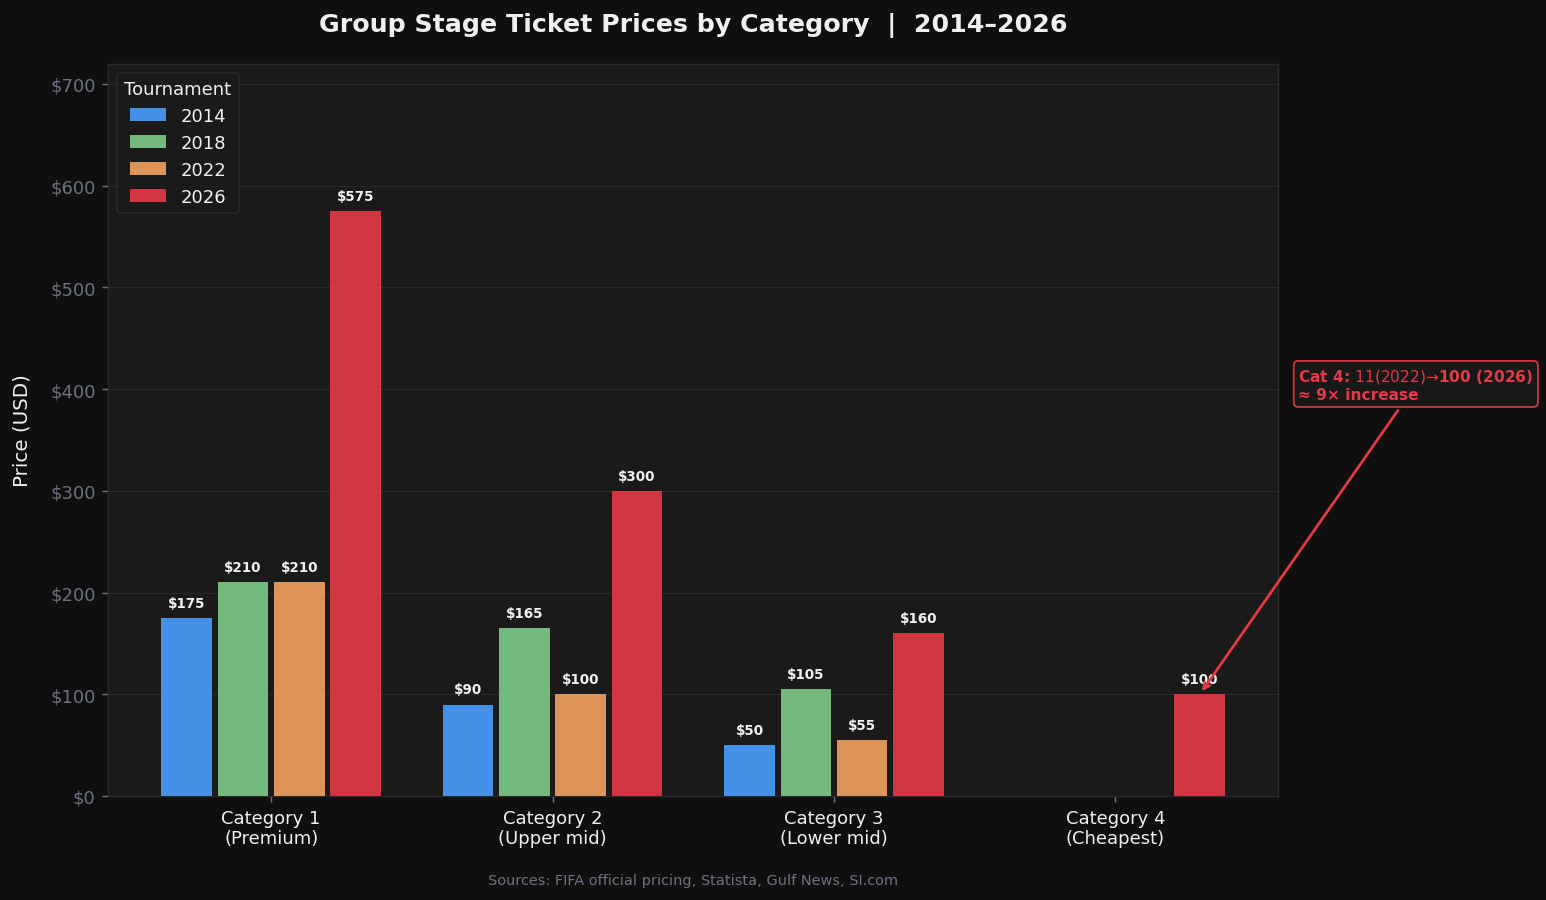

In [25]:
# ── Chart 1: Group stage prices by category ───────────────────────────────────
group_stage = tickets[
    (tickets["stage"] == "Group stage") &
    (~tickets["category"].str.contains("residents"))
].copy()

cats  = ["Cat1", "Cat2", "Cat3", "Cat4"]
years = [2014, 2018, 2022, 2026]
x     = np.arange(len(cats))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 7))

for i, year in enumerate(years):
    yr_data = group_stage[group_stage["year"] == year]
    prices  = []
    for cat in cats:
        row = yr_data[yr_data["category"] == cat]
        prices.append(row["price_usd"].values[0] if len(row) > 0 else 0)

    bars = ax.bar(x + i * width, prices, width=width - 0.02,
                  color=YEAR_COLOURS[year], alpha=0.9, label=str(year), zorder=3)
    for bar, price in zip(bars, prices):
        if price > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                    f"${price:,.0f}", ha="center", va="bottom",
                    fontsize=7.5, color=WHITE, fontweight="bold")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(["Category 1\n(Premium)", "Category 2\n(Upper mid)",
                     "Category 3\n(Lower mid)", "Category 4\n(Cheapest)"],
                   fontsize=10, color=WHITE)
ax.set_ylabel("Price (USD)", fontsize=11, labelpad=10)
ax.set_ylim(0, 720)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.grid(axis="y", zorder=0)
ax.set_axisbelow(True)
ax.legend(title="Tournament", fontsize=10, loc="upper left",
          facecolor=PANEL, edgecolor=GRID, labelcolor=WHITE)
ax.set_title("Group Stage Ticket Prices by Category  |  2014–2026",
             fontsize=14, fontweight="bold", pad=18)
ax.annotate(
    "Cat 4: $11 (2022) → $100 (2026)\n≈ 9× increase",
    xy=(x[3] + 3 * width, 100), xytext=(x[3] + 3 * width + 0.35, 390),
    arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.5),
    fontsize=8.5, color=ACCENT, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL, edgecolor=ACCENT, alpha=0.9),
)
ax.text(0.5, -0.12, "Sources: FIFA official pricing, Statista, Gulf News, SI.com",
        transform=ax.transAxes, fontsize=8, color=MUTED, ha="center")

plt.tight_layout()
plt.show()

The chart above makes the price inflation impossible to ignore. Across every ticket category, 2026 stands apart, not by a little, but by a lot.

What is striking is not just the scale of the increase, but where it hits hardest. Category 1, the premium seats bought by corporates and hospitality packages, has risen from USD 175 in 2014 to USD 575 in 2026, roughly a 3x increase over twelve years. Steep, but not shocking for premium pricing in an inflated market.

The real story is at the other end. Category 4, the ticket designed for the ordinary fan, has gone from USD 11 in Qatar to USD 100 in the US. Nine times more expensive. And unlike Qatar, where that USD 11 price was reserved for residents, the USD 100 is the floor for everyone. There is no concession for the travelling supporter who has saved up, booked flights, and flown across the world to watch their country play.

Notice also that Category 4 only has a 2026 bar. That is not a data error. In every prior tournament, the cheapest category was either reserved for residents or structured differently. In 2026, there is no resident pricing at all. Every fan, local or international, pays the same premium rate.

FIFA justified this with dynamic pricing, the idea that tickets find their natural market value. What it produced in practice was a tournament where the atmosphere inside stadiums is determined not by passion, but by purchasing power.

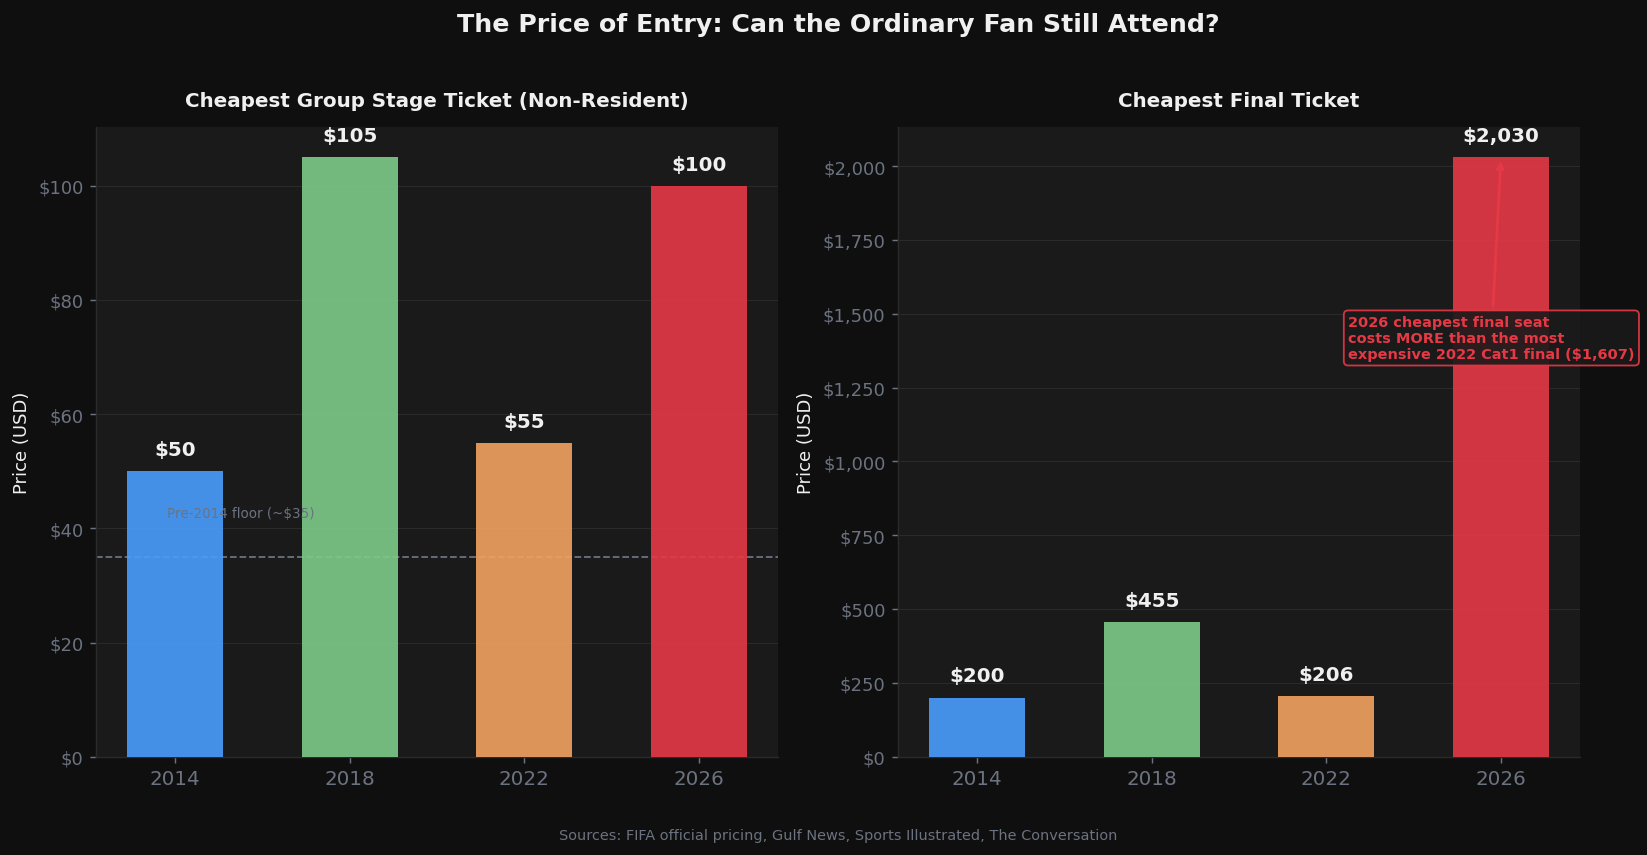

In [26]:
# ── Chart 2: Cheapest ticket floor — group stage & final ─────────────────────
fan_floor      = {2014: 50,  2018: 105, 2022: 55,  2026: 100}
final_cheapest = {2014: 200, 2018: 455, 2022: 206, 2026: 2030}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("The Price of Entry: Can the Ordinary Fan Still Attend?",
             fontsize=14, fontweight="bold", color=WHITE, y=1.02)

for ax, (data, title) in zip(axes, [
    (fan_floor,      "Cheapest Group Stage Ticket (Non-Resident)"),
    (final_cheapest, "Cheapest Final Ticket"),
]):
    ax.set_facecolor(PANEL)
    yrs     = list(data.keys())
    vals    = list(data.values())
    colours = [YEAR_COLOURS[y] for y in yrs]

    bars = ax.bar(yrs, vals, color=colours, width=2.2, zorder=3, alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.02,
                f"${val:,}", ha="center", va="bottom",
                fontsize=11, color=WHITE, fontweight="bold")

    if "Group" in title:
        ax.axhline(35, color=MUTED, linestyle="--", linewidth=1, zorder=2)
        ax.text(2013.8, 42, "Pre-2014 floor (~$35)", fontsize=7.5, color=MUTED)

    ax.set_title(title, fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel("Price (USD)", fontsize=10)
    ax.set_xticks(yrs)
    ax.set_xticklabels(yrs, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

axes[1].annotate(
    "2026 cheapest final seat\ncosts MORE than the most\nexpensive 2022 Cat1 final ($1,607)",
    xy=(2026, 2030), xytext=(2022.5, 1350),
    arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.5),
    fontsize=8, color=ACCENT, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL, edgecolor=ACCENT, alpha=0.9),
)
fig.text(0.5, -0.04,
         "Sources: FIFA official pricing, Gulf News, Sports Illustrated, The Conversation",
         ha="center", fontsize=8, color=MUTED)

plt.tight_layout()
plt.show()

The left panel looks almost reasonable at first glance. USD 100 for a group stage match is expensive, but not outrageous. Russia in 2018 actually charged USD 105 for the same tier. If you stopped the analysis there, you might conclude the pricing story has been exaggerated.

Then you look at the right panel.

The three bars on the left of the Final chart, 2014, 2018, 2022, sit in a range that a dedicated football fan could, with planning and sacrifice, realistically afford. Between USD 200 and USD 455. The kind of money that hurts but does not break you. Then 2026 arrives, and the scale of the chart has to stretch to accommodate it. USD 2,030, for the cheapest seat in the house.

The annotation says it plainly: that price is higher than the most expensive Category 1 Final ticket in Qatar. The best seat at the last World Cup Final cost less than the worst seat at this one. It is the single most damning number in this entire dataset.

There is a broader context worth noting too. The dashed line on the left chart marks the pre-2014 floor of roughly USD 35, the price at which a World Cup ticket was, for most of its history, within reach of a working person. That era ended twelve years ago and has not returned. But 2026 does not just continue that trend. It breaks it entirely, moving the tournament into a bracket previously occupied only by the Super Bowl and the Champions League final, events that have never pretended to be for everyone.

The question the right panel implicitly asks is: who, exactly, is the 2026 World Cup for?

## 3. Stadium Attendance

### Context
Every World Cup from 2006 to 2022 achieved **94%+ stadium fill rates**.  
In 2026, opening matches in the US and Canada were not sold out.  
The FIFA resale portal had **176,000 unsold tickets** across the group stage opening.  
Hotels that priced rooms at tournament premiums are now cutting rates to stimulate demand.

> *Sources: FIFA official records, Statista, FootyStats, Financial Times*

---

In [27]:
# ── Preview the attendance data ───────────────────────────────────────────────
print("=== Attendance Dataset ===")
display(attendance)

=== Attendance Dataset ===


,year,host,total_attendance,matches,avg_attendance_per_match,capacity_fill_pct,notes
0,1994,United States,3587538.0,52,68991.0,99.8,All-time attendance record; near-perfect fill ...
1,2006,Germany,3359439.0,64,52491.0,98.0,High fill rate in purpose-built/renovated venues
2,2010,South Africa,3178856.0,64,49670.0,94.0,Below expectations but solid
3,2014,Brazil,3429873.0,64,53592.0,97.0,Strong despite protests - all matches sold out
4,2018,Russia,3031768.0,64,47372.0,97.0,Some empty seats but broadly full
5,2022,Qatar,3404252.0,64,53191.0,95.5,Surprisingly strong given small nation and off...
6,2026,United States,NaN,104,NaN,NaN,176000 resale tickets unsold at group stage op...


In [28]:
# ── Key stats ─────────────────────────────────────────────────────────────────
hist = attendance[attendance["year"] != 2026].copy()

print("=== Historical Attendance Summary ===\n")
print(f"Highest avg attendance per match : {hist['avg_attendance_per_match'].max():,.0f} "
      f"({hist.loc[hist['avg_attendance_per_match'].idxmax(), 'host']} "
      f"{hist.loc[hist['avg_attendance_per_match'].idxmax(), 'year']})")
print(f"Lowest avg attendance per match  : {hist['avg_attendance_per_match'].min():,.0f} "
      f"({hist.loc[hist['avg_attendance_per_match'].idxmin(), 'host']} "
      f"{hist.loc[hist['avg_attendance_per_match'].idxmin(), 'year']})")
print(f"Average fill rate across all prior hosts : "
      f"{hist['capacity_fill_pct'].mean():.1f}%")
print(f"\n2026 context: opening matches not sold out; 176,000 resale tickets unsold")

=== Historical Attendance Summary ===

Highest avg attendance per match : 68,991 (United States 1994)
Lowest avg attendance per match  : 47,372 (Russia 2018)
Average fill rate across all prior hosts : 96.9%

2026 context: opening matches not sold out; 176,000 resale tickets unsold


There is an uncomfortable irony buried in this summary. The highest average attendance in World Cup history belongs to the United States in 1994, 68,991 fans per match, across 52 games, at 99.8% capacity. That tournament set a record that has stood for 32 years and has never seriously been threatened.

America, in other words, knows exactly how to fill a football stadium. It did it better than anyone, ever. That makes what is happening in 2026 not just a disappointment but a genuine puzzle, and on closer inspection, an indictment.

The six tournaments between 2006 and 2022 averaged a 96.9% fill rate. Not one of them dropped below 94%. Germany, South Africa, Brazil, Russia, Qatar, countries with wildly different football cultures, infrastructure levels, and geopolitical contexts, all managed to put bodies in seats. Some, like Qatar, were written off in advance as too small, too hot, too unfamiliar. They delivered anyway.

The 2026 tournament opened with unsold seats at its first matches and 176,000 resale tickets still sitting on FIFA's own platform as the group stage began. For a World Cup that received 500 million ticket requests, ten times the total available inventory, that is a remarkable failure of conversion. The demand was there. What drove fans away will become clear in the sections that follow.

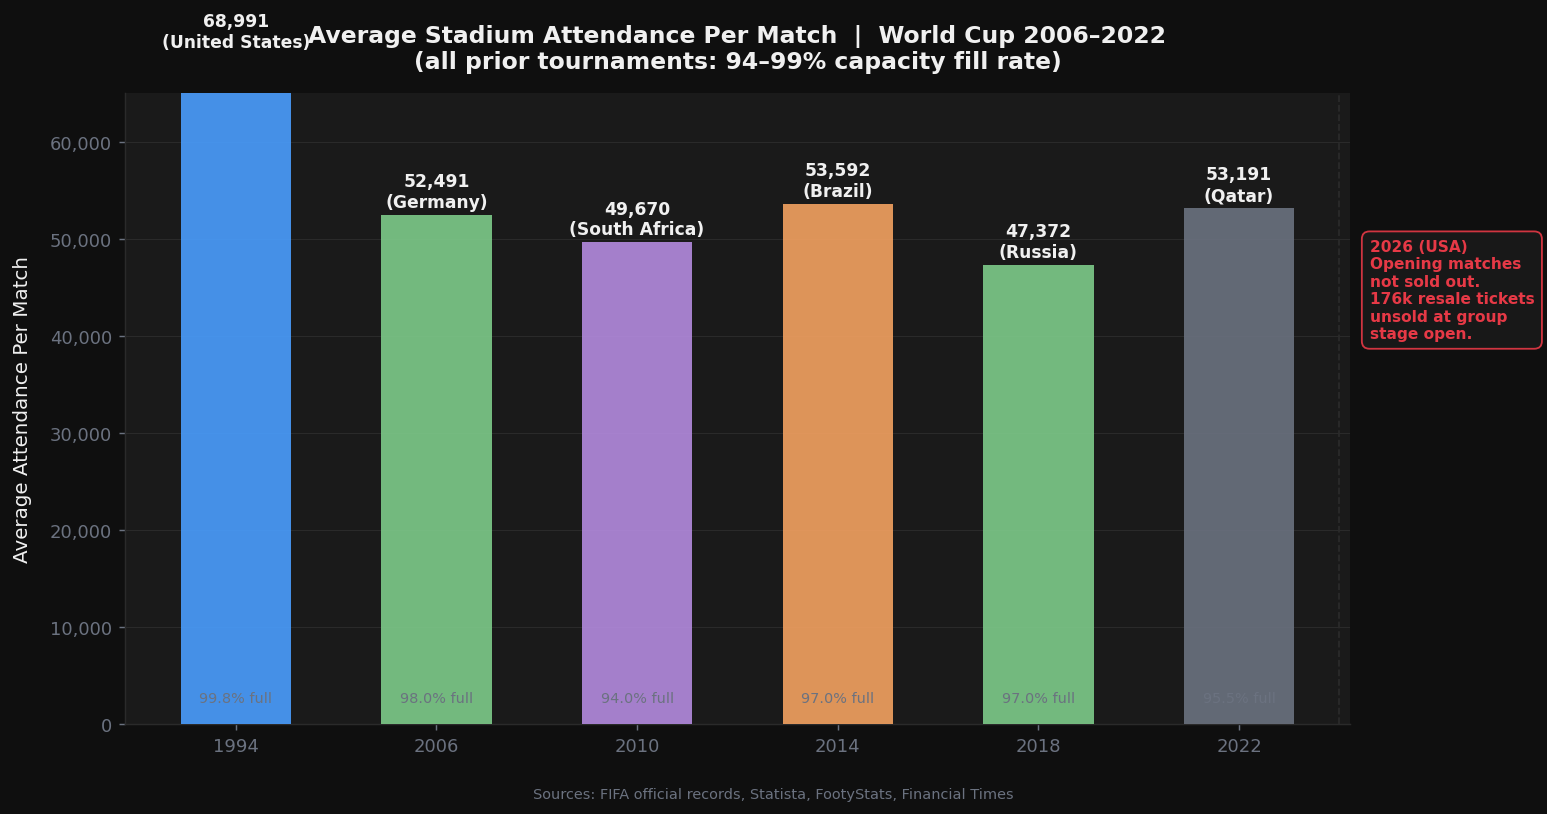

In [29]:
# ── Chart 3: Average attendance per match ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

bar_colours = ["#4a9eff", "#7ecb8a", "#b48be0", "#f4a261", "#7ecb8a", MUTED]
bars = ax.bar(hist["year"].astype(str), hist["avg_attendance_per_match"],
              color=bar_colours[:len(hist)], width=0.55, zorder=3, alpha=0.9)

for bar, row in zip(bars, hist.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 400,
            f"{row.avg_attendance_per_match:,.0f}\n({row.host})",
            ha="center", va="bottom", fontsize=9.5, color=WHITE, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width() / 2, 2000,
            f"{row.capacity_fill_pct}% full",
            ha="center", va="bottom", fontsize=8, color=MUTED)

ax.axvline(x=5.5, color=GRID, linestyle="--", linewidth=1)
ax.text(5.65, 50000,
        "2026 (USA)\nOpening matches\nnot sold out.\n176k resale tickets\nunsold at group\nstage open.",
        fontsize=8.5, color=ACCENT, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.5", facecolor=PANEL, edgecolor=ACCENT, alpha=0.9),
        va="top")

ax.set_ylim(0, 65000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_ylabel("Average Attendance Per Match", fontsize=11, labelpad=10)
ax.set_title("Average Stadium Attendance Per Match  |  World Cup 2006–2022\n"
             "(all prior tournaments: 94–99% capacity fill rate)",
             fontsize=13, fontweight="bold", pad=14)
ax.grid(axis="y", zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.5, -0.03,
         "Sources: FIFA official records, Statista, FootyStats, Financial Times",
         ha="center", fontsize=8, color=MUTED)

plt.tight_layout()
plt.show()

Look at the consistency of those six bars. Across three decades, six countries, six completely different hosting contexts, the numbers barely waver. Germany in 2006: 98% full. South Africa in 2010, a continent hosting its first-ever World Cup with stadiums still being finished weeks before kickoff: 94% full. Qatar in 2022, a country of three million people hosting 32 teams in a tournament that most of the football world thought should never have been held there: 95.5% full.

The World Cup, it turns out, sells itself. Every host since 1994 has managed to fill their stadiums, not because they were perfect hosts, but because the demand for World Cup football is so enormous that it overcomes almost any obstacle. Bad infrastructure, geopolitical controversy, extreme heat, a nine-hour time difference from Europe, none of it has ever been enough to leave seats empty.

Until now.

The red annotation sitting to the right of the chart, detached, with no bar to stand on, is the 2026 story in three lines. Opening matches not sold out. 176,000 resale tickets unsold as the group stage began. For a tournament that generated 500 million ticket requests, this is not a demand problem. Something else is keeping people away.

That something else is what the next two sections examine. First, the collapse in tourism to the United States that predated the tournament entirely. Then, the immigration policies that turned the act of attending a World Cup match into a legal obstacle course for fans from dozens of qualifying nations.

The stadiums are there. The fans wanted to come. The question is what stopped them.

## 4. Tourism Decline

### Context
Every prior World Cup host saw a tourism **increase** in their host year.  
The US is the only host projected to see a **decline**, and this was already happening before the tournament began.  
In 2025, international visitors to the US fell 3.7% vs 2024, the first year-on-year drop since the pandemic.  
Tourism Economics estimated a **9.4% decline** in international visitors to the US for 2025.  
Canada alone accounted for a drop of **3.5 million visitors**.

> *Sources: ITA/NTTO, Congress.gov, Tourism Economics, UN Tourism*

---

In [30]:
# ── Preview the tourism data ──────────────────────────────────────────────────
print("=== Tourism Dataset ===")
display(tourism)

=== Tourism Dataset ===


,year,country,inbound_visitors_millions,world_cup_host,notes
0,2013,Brazil,5.81,0,Pre-WC year
1,2014,Brazil,6.43,1,WC host year - record at time
2,2015,Brazil,6.36,0,Post-WC year
3,2017,Russia,24.40,0,Pre-WC year
4,2018,Russia,24.60,1,WC host year (modest bump due to WC)
5,2019,Russia,24.40,0,Post-WC year
6,2021,Qatar,0.59,0,Pre-WC year (pandemic)
7,2022,Qatar,2.61,1,WC host year (Nov-Dec tournament)
8,2023,Qatar,4.09,0,Post-WC boom
9,2019,United States,79.40,0,Pre-pandemic peak


In [31]:
# ── US tourism trend analysis ─────────────────────────────────────────────────
us = tourism[tourism["country"] == "United States"].copy().sort_values("year")

print("=== US Inbound Visitors: Year-on-Year Change ===\n")
us["yoy_change"] = us["inbound_visitors_millions"].pct_change() * 100
us["vs_2019_peak"] = (us["inbound_visitors_millions"] / 79.4 - 1) * 100

display(us[["year", "inbound_visitors_millions", "yoy_change", "vs_2019_peak",
            "world_cup_host", "notes"]])

print(f"\nProjected 2026 visitors: 62.0M")
print(f"That is {(62.0 / 79.4 - 1) * 100:.1f}% below the 2019 peak of 79.4M")
print(f"And {(62.0 / 72.4 - 1) * 100:.1f}% below 2024")

=== US Inbound Visitors: Year-on-Year Change ===



,year,inbound_visitors_millions,yoy_change,vs_2019_peak,world_cup_host,notes
9,2019,79.4,NaN,0.000000,0,Pre-pandemic peak
10,2022,50.8,-36.020151,-36.020151,0,Recovery year
11,2023,66.5,30.905512,-16.246851,0,Continued recovery
12,2024,72.4,8.872180,-8.816121,0,Still below 2019 peak
13,2025,68.3,-5.662983,-13.979849,0,First YoY decline since 2020 - Trump effect
14,2026,62.0,-9.224012,-21.914358,1,WC host year - projected decline (Tourism Econ...



Projected 2026 visitors: 62.0M
That is -21.9% below the 2019 peak of 79.4M
And -14.4% below 2024


The numbers in that table tell a story that begins well before the first whistle blew in June 2026.

After the pandemic gutted international travel, US visitor numbers collapsed to 50.8 million in 2022, barely half the 2019 peak. The recovery was textbook. 2023 up 31%. 2024 up another 9%. The trajectory was clear: America was on course to reclaim its position as one of the world's premier tourist destinations, potentially hitting its 90 million visitor target ahead of schedule.

Then 2025 happened. Visitors fell to 68.3 million, a 5.7% drop, the first year-on-year decline since the depths of the pandemic. This was not a blip caused by a weak economy or a natural disaster. It was, as the note in the dataset says plainly, the Trump effect. Travel bans, visa uncertainty, reports of phones being searched at borders, and a broader global perception that the United States had become an unwelcoming destination combined to reverse three years of recovery in a single year.

By 2026, the year the US was supposed to be showcasing itself to the world, the projection sits at 62 million visitors. That is 21.9% below the 2019 peak. It is 14.4% below where the country was just two years earlier. And it is happening in the same summer that FIFA estimated ten million people would travel to the US for the World Cup alone.

Every other World Cup host has seen tourism increase in its tournament year. The US is on course to be the first in modern history to see it fall, and to fall sharply, in a year when the entire planet had a reason to visit.

In [32]:
# ── Host benchmark data ───────────────────────────────────────────────────────
print("=== Tourism in World Cup Year vs Prior Year ===\n")

benchmark = [
    {"host": "Brazil",         "year": 2014, "wc_year": 6.43,  "prior_year": 5.81,
     "colour": "#4a9eff"},
    {"host": "Russia",         "year": 2018, "wc_year": 24.6,  "prior_year": 24.4,
     "colour": "#7ecb8a"},
    {"host": "Qatar",          "year": 2022, "wc_year": 2.61,  "prior_year": 0.59,
     "colour": "#f4a261"},
    {"host": "United States",  "year": 2026, "wc_year": 62.0,  "prior_year": 68.3,
     "colour": ACCENT},
]
bench_df = pd.DataFrame(benchmark)
bench_df["pct_change"] = (bench_df["wc_year"] - bench_df["prior_year"]) / bench_df["prior_year"] * 100

display(bench_df[["host", "year", "prior_year", "wc_year", "pct_change"]]
        .rename(columns={"prior_year": "visitors_prior_yr_M",
                         "wc_year":    "visitors_wc_yr_M",
                         "pct_change": "pct_change_vs_prior"}))

=== Tourism in World Cup Year vs Prior Year ===



,host,year,visitors_prior_yr_M,visitors_wc_yr_M,pct_change_vs_prior
0,Brazil,2014,5.81,6.43,10.671256
1,Russia,2018,24.40,24.60,0.819672
2,Qatar,2022,0.59,2.61,342.372881
3,United States,2026,68.30,62.00,-9.224012


That final row is the one that matters. Set it against the other three and the scale of the failure becomes undeniable.

Brazil in 2014 was a country in economic turmoil, with street protests running alongside the tournament. It still grew tourism by 10.7%. Russia in 2018 was under international sanctions, had been accused of election interference, and faced an active Western diplomatic chill. England fans were widely advised not to travel. It still edged up 0.8%. Qatar in 2022 was a country that had never hosted anything close to this scale, with stadiums built in the desert and accommodation so limited that fans were sleeping on cruise ships. The World Cup effect was so powerful it drove a 342% surge in visitors anyway.

Then there is the United States. The largest economy on earth. A country with world-class airports, abundant hotels, an existing sports infrastructure that runs 104 events simultaneously without breaking a sweat, and 32 years of experience hosting a World Cup before. A country that, in 1994, set the all-time attendance record that still stands today.

**Minus 9.2%.**

Not a modest gain. Not a flat year. A near double-digit decline, in a World Cup year, against a prior year that was itself already below peak. Qatar, a country the size of Connecticut with a population of three million, managed to more than quadruple its visitor numbers during its tournament. The US, with every conceivable advantage, is on course to welcome 6.3 million fewer people than it did the year before.

The difference between those four rows is not infrastructure, or footballing culture, or stadium capacity. It is political will, and what happens when a host government treats the arrival of the world as a threat rather than an opportunity.

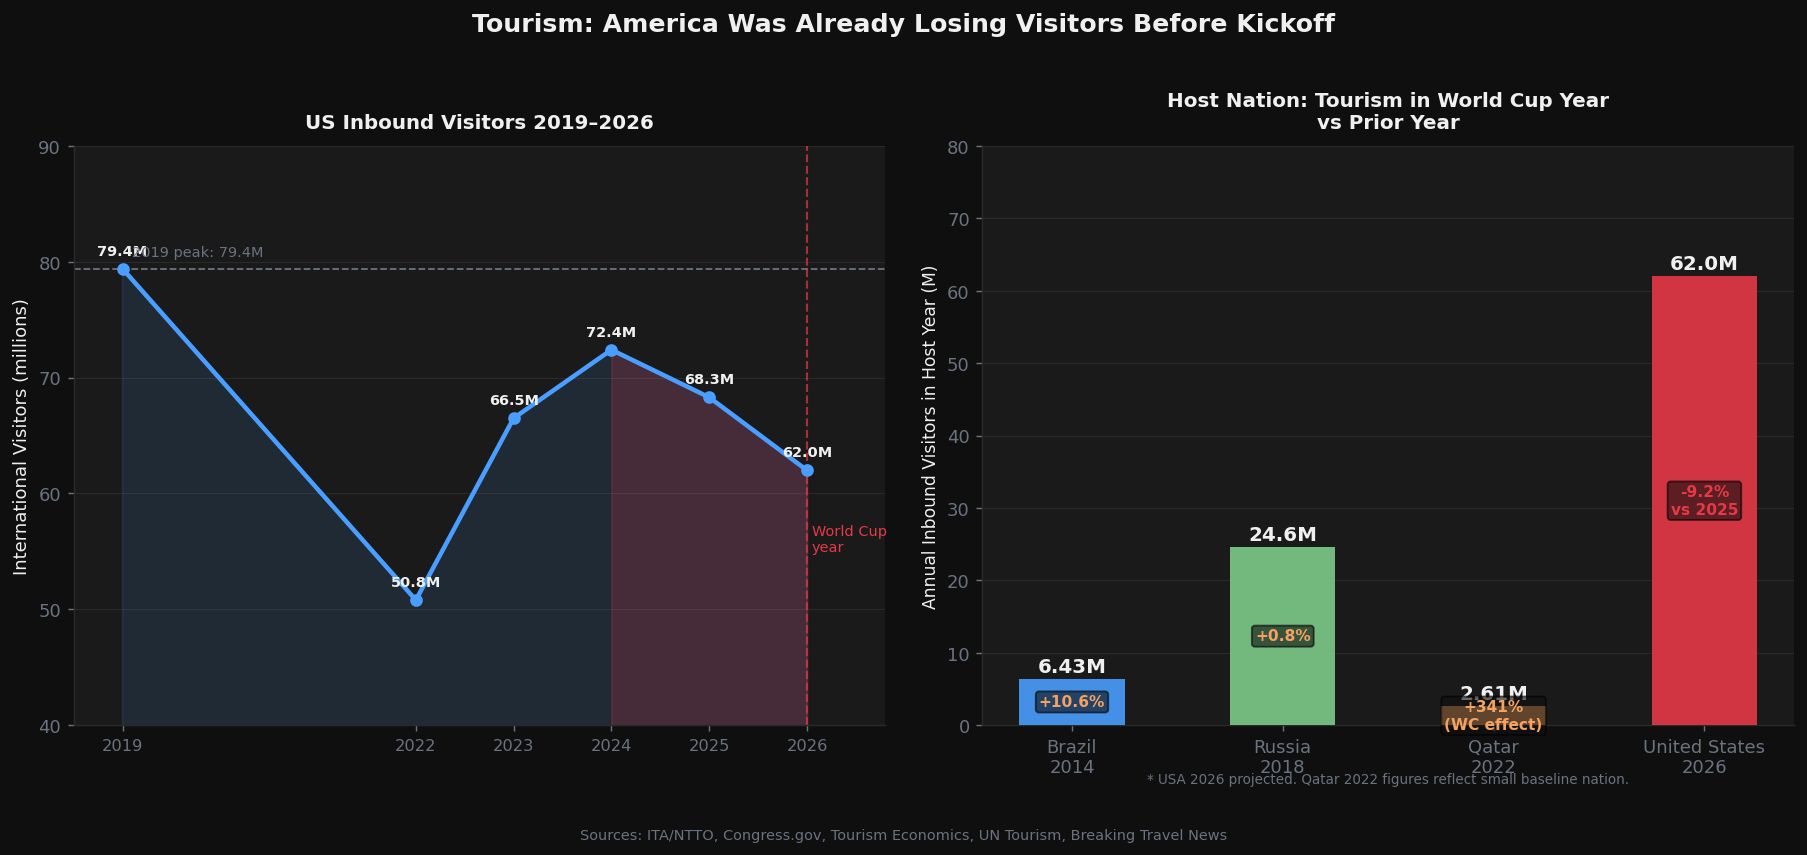

In [39]:
# ── Chart 4: Tourism decline ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Tourism: America Was Already Losing Visitors Before Kickoff",
             fontsize=14, fontweight="bold", color=WHITE, y=1.02)

# Left: US trend line
ax = axes[0]
ax.set_facecolor(PANEL)
line_colour = "#4a9eff"

ax.plot(us["year"], us["inbound_visitors_millions"],
        color=line_colour, linewidth=2.5, zorder=3, marker="o", markersize=6)
ax.fill_between(us["year"], us["inbound_visitors_millions"], alpha=0.12, color=line_colour)

decline = us[us["year"] >= 2024]
ax.fill_between(decline["year"], decline["inbound_visitors_millions"],
                alpha=0.2, color=ACCENT)

for _, row in us.iterrows():
    ax.text(row["year"], row["inbound_visitors_millions"] + 1.2,
            f"{row['inbound_visitors_millions']}M",
            ha="center", fontsize=8, color=WHITE, fontweight="bold")

ax.axhline(79.4, color=MUTED, linestyle="--", linewidth=1)
ax.text(2019.1, 80.5, "2019 peak: 79.4M", fontsize=8, color=MUTED)
ax.axvline(2026, color=ACCENT, linestyle="--", linewidth=1.2, alpha=0.7)
ax.text(2026.05, 55, "World Cup\nyear", fontsize=8, color=ACCENT)

ax.set_xlim(2018.5, 2026.8)
ax.set_ylim(40, 90)
ax.set_ylabel("International Visitors (millions)", fontsize=10)
ax.set_title("US Inbound Visitors 2019–2026", fontsize=11, fontweight="bold", pad=10)
ax.grid(axis="y", zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks(us["year"])
ax.set_xticklabels(us["year"].astype(int), fontsize=9)

# Right: host benchmark bars
ax = axes[1]
ax.set_facecolor(PANEL)

labels  = [f"{d['host']}\n{d['year']}" for d in benchmark]
vals    = [d["wc_year"] for d in benchmark]
colours = [d["colour"] for d in benchmark]
trends  = ["+10.6%", "+0.8%", "+341%\n(WC effect)", "-9.2%\nvs 2025"]
trend_colours = [GOLD, GOLD, GOLD, ACCENT]

bars = ax.bar(labels, vals, color=colours, width=0.5, zorder=3, alpha=0.9)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{val}M", ha="center", va="bottom",
            fontsize=11, color=WHITE, fontweight="bold")

for bar, trend, tc in zip(bars, trends, trend_colours):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
            trend, ha="center", va="center", fontsize=8.5,
            color=tc, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor=BG, alpha=0.6))

ax.set_ylabel("Annual Inbound Visitors in Host Year (M)", fontsize=9.5)
ax.set_title("Host Nation: Tourism in World Cup Year\nvs Prior Year",
             fontsize=11, fontweight="bold", pad=10)
ax.set_ylim(0, 80)
ax.grid(axis="y", zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.text(0.5, -0.1, "* USA 2026 projected. Qatar 2022 figures reflect small baseline nation.",
        transform=ax.transAxes, fontsize=7.5, color=MUTED, ha="center")

fig.text(0.5, -0.04,
         "Sources: ITA/NTTO, Congress.gov, Tourism Economics, UN Tourism, Breaking Travel News",
         ha="center", fontsize=8, color=MUTED)

plt.tight_layout()
plt.show()

The left panel shows the shape of a recovery that never quite finished. The post-pandemic rebound from 2022 to 2024 was real and meaningful; 21.6 million visitors recovered in two years. But notice where the line peaks: 72.4 million in 2024, still more than seven million short of the 2019 level marked by the dashed line. America had not yet reclaimed its pre-pandemic standing as a tourist destination before the decline began again.

The shaded red region from 2024 onwards is the part that matters. The line doesn't flatten. It doesn't plateau at 72 million and hold. It falls, first to 68.3 million in 2025, then to a projected 62 million in 2026, the World Cup year. That downward slope through a shaded warning zone, terminating at the red dashed line marking the tournament, is the visual summary of everything this section has tried to say. The world was not deterred from coming to America by lack of interest. It was deterred before a single match was played.

The right panel reframes the same story as a comparison, and the US bar's scale is initially misleading; 62 million looks enormous next to Qatar's 2.61 million. But the percentage labels embedded in each bar strip away the size advantage. Brazil: +10.6%. Russia: +0.8%. Qatar: +341%. United States: –3.7%. The only red label. The only minus sign. The only host in this dataset that welcomed fewer people in its World Cup year than the year before.

The title of this chart, America Was Already Losing Visitors Before Kickoff, is not hyperbole. It is what the data says.

## 5. Fan Access Barriers

### Context
20% of all countries on earth (39 of 195) face US travel restrictions.  
**4 qualified nations** are under full or partial travel bans: Haiti, Iran, Ivory Coast, Senegal.  
**Iran's** entire support staff allocation was denied visas; the squad is based in Mexico, commuting to US matches.  
**40+ Moroccan** supporter association members were denied visas despite holding tickets and hotel bookings.  
ICE confirmed it will have agents **inside stadiums**.

> *Sources: CFR, American Immigration Council, Wego Travel, FIFA, Reuters, NPR*

---

In [34]:
# ── Preview the barriers data ─────────────────────────────────────────────────
print("=== Access Barriers Dataset ===")
display(barriers.sort_values("barrier_score", ascending=False))

=== Access Barriers Dataset ===


,country,confederation,travel_ban_level,visa_bond_required,immigrant_visa_freeze,ice_at_stadiums,staff_denied_entry,fan_ticket_allocation_revoked,barrier_score,notes
1,Iran,AFC,Full ban,No,Yes,Yes,Yes,Yes,6,Full ban; 15+ staff denied visas; ticket alloc...
0,Haiti,CONCACAF,Full ban,No,Yes,Yes,No,No,5,Full travel ban; fans cannot attend US matches
2,Ivory Coast,CAF,Partial restriction,Yes (waived for PASS),No,Yes,No,No,3,Partial restrictions; visa bond waived for tic...
3,Senegal,CAF,Partial restriction,Yes (waived for PASS),No,Yes,No,No,3,Partial restrictions; visa bond waived for tic...
8,Tunisia,CAF,No ban,Yes (waived for PASS),Yes (immigrant only),Yes,No,No,3,Visa bond previously required + immigrant freeze
9,Cabo Verde,CAF,No ban,Yes (waived for PASS),Yes (immigrant only),Yes,No,No,3,Visa bond previously required
11,Uruguay,CONMEBOL,No ban,No,Yes (immigrant only),Yes,No,No,2,Immigrant visa freeze - notable given Uruguay'...
15,Guatemala,CONCACAF,No ban,No,Yes (immigrant only),Yes,No,No,2,Immigrant visa freeze
14,Brazil,CONMEBOL,No ban,No,Yes (immigrant only),Yes,No,No,2,Immigrant visa freeze - remarkable given Brazi...
12,Uzbekistan,AFC,No ban,No,Yes (immigrant only),Yes,No,No,2,Immigrant visa freeze


In [35]:
# ── Summary by barrier type ───────────────────────────────────────────────────
print("=== Nations Affected by Each Barrier Type ===\n")

total_qualified = 48

full_ban     = barriers[barriers["travel_ban_level"] == "Full ban"]
partial_ban  = barriers[barriers["travel_ban_level"] == "Partial restriction"]
visa_freeze  = barriers[barriers["immigrant_visa_freeze"] == "Yes"]
visa_bond    = barriers[barriers["visa_bond_required"].str.contains("Yes", na=False)]
staff_denied = barriers[barriers["staff_denied_entry"] == "Yes"]

print(f"Full travel ban (fans cannot enter US)     : {len(full_ban)} nations  — "
      f"{', '.join(full_ban['country'].tolist())}")
print(f"Partial travel ban                         : {len(partial_ban)} nations  — "
      f"{', '.join(partial_ban['country'].tolist())}")
print(f"Immigrant visa freeze                      : {len(visa_freeze)} nations")
print(f"Visa bond required (or previously required): {len(visa_bond)} nations")
print(f"Team/staff denied entry                    : {len(staff_denied)} nations  — "
      f"{', '.join(staff_denied['country'].tolist())}")
print(f"\nICE confirmed at stadiums                  : ALL host city venues")
print(f"\nTotal nations with any barrier (score ≥ 2) : "
      f"{len(barriers[barriers['barrier_score'] >= 2])} in our sample")

=== Nations Affected by Each Barrier Type ===

Full travel ban (fans cannot enter US)     : 2 nations  — Haiti, Iran
Partial travel ban                         : 2 nations  — Ivory Coast, Senegal
Immigrant visa freeze                      : 2 nations
Visa bond required (or previously required): 4 nations
Team/staff denied entry                    : 1 nations  — Iran

ICE confirmed at stadiums                  : ALL host city venues

Total nations with any barrier (score ≥ 2) : 16 in our sample


Sixteen nations. Nearly a third of the 48 teams competing in this tournament have fans who face some form of legal barrier to entering the United States to watch them play.

Start with the hardest cases. Haiti and Iran are under full travel bans. Their supporters cannot obtain the B-2 tourist visa required to attend a match on US soil. Haiti's qualification was one of the most remarkable stories of this entire tournament, their first World Cup since 1974, achieved without being able to play a single home match inside a country torn apart by gang violence. They made it to the biggest stage in football. Their fans cannot follow them there.

Iran's situation is more complicated and more troubling. The players themselves were eventually granted visas, but at least 15 members of the team's support staff were denied entry. The squad has been based in Mexico, commuting across the border for matches. FIFA then revoked Iran's entire fan ticket allocation, thousands of seats that had been set aside for Iranian supporters, days before their first game. The team is technically participating. Functionally, they are doing so without a home.

Ivory Coast and Senegal face partial restrictions. Their fans can apply for visas, but the process is laden with additional scrutiny, financial requirements, and uncertainty that for many amounts to a practical ban.

Then there is the detail that applies to every single fan who does make it through: ICE agents are confirmed at all host city venues. The Department of Homeland Security was explicit that immigration enforcement would not be suspended during the tournament. For the millions of immigrants already living in the US, many of whom are the most passionate football supporters in the country, attending a match means entering a stadium where federal agents are present with enforcement authority. Many will have chosen not to take that risk.

The World Cup has always been complicated. But it has never before asked fans to weigh their legal status against their love of the game just to sit in the stands.

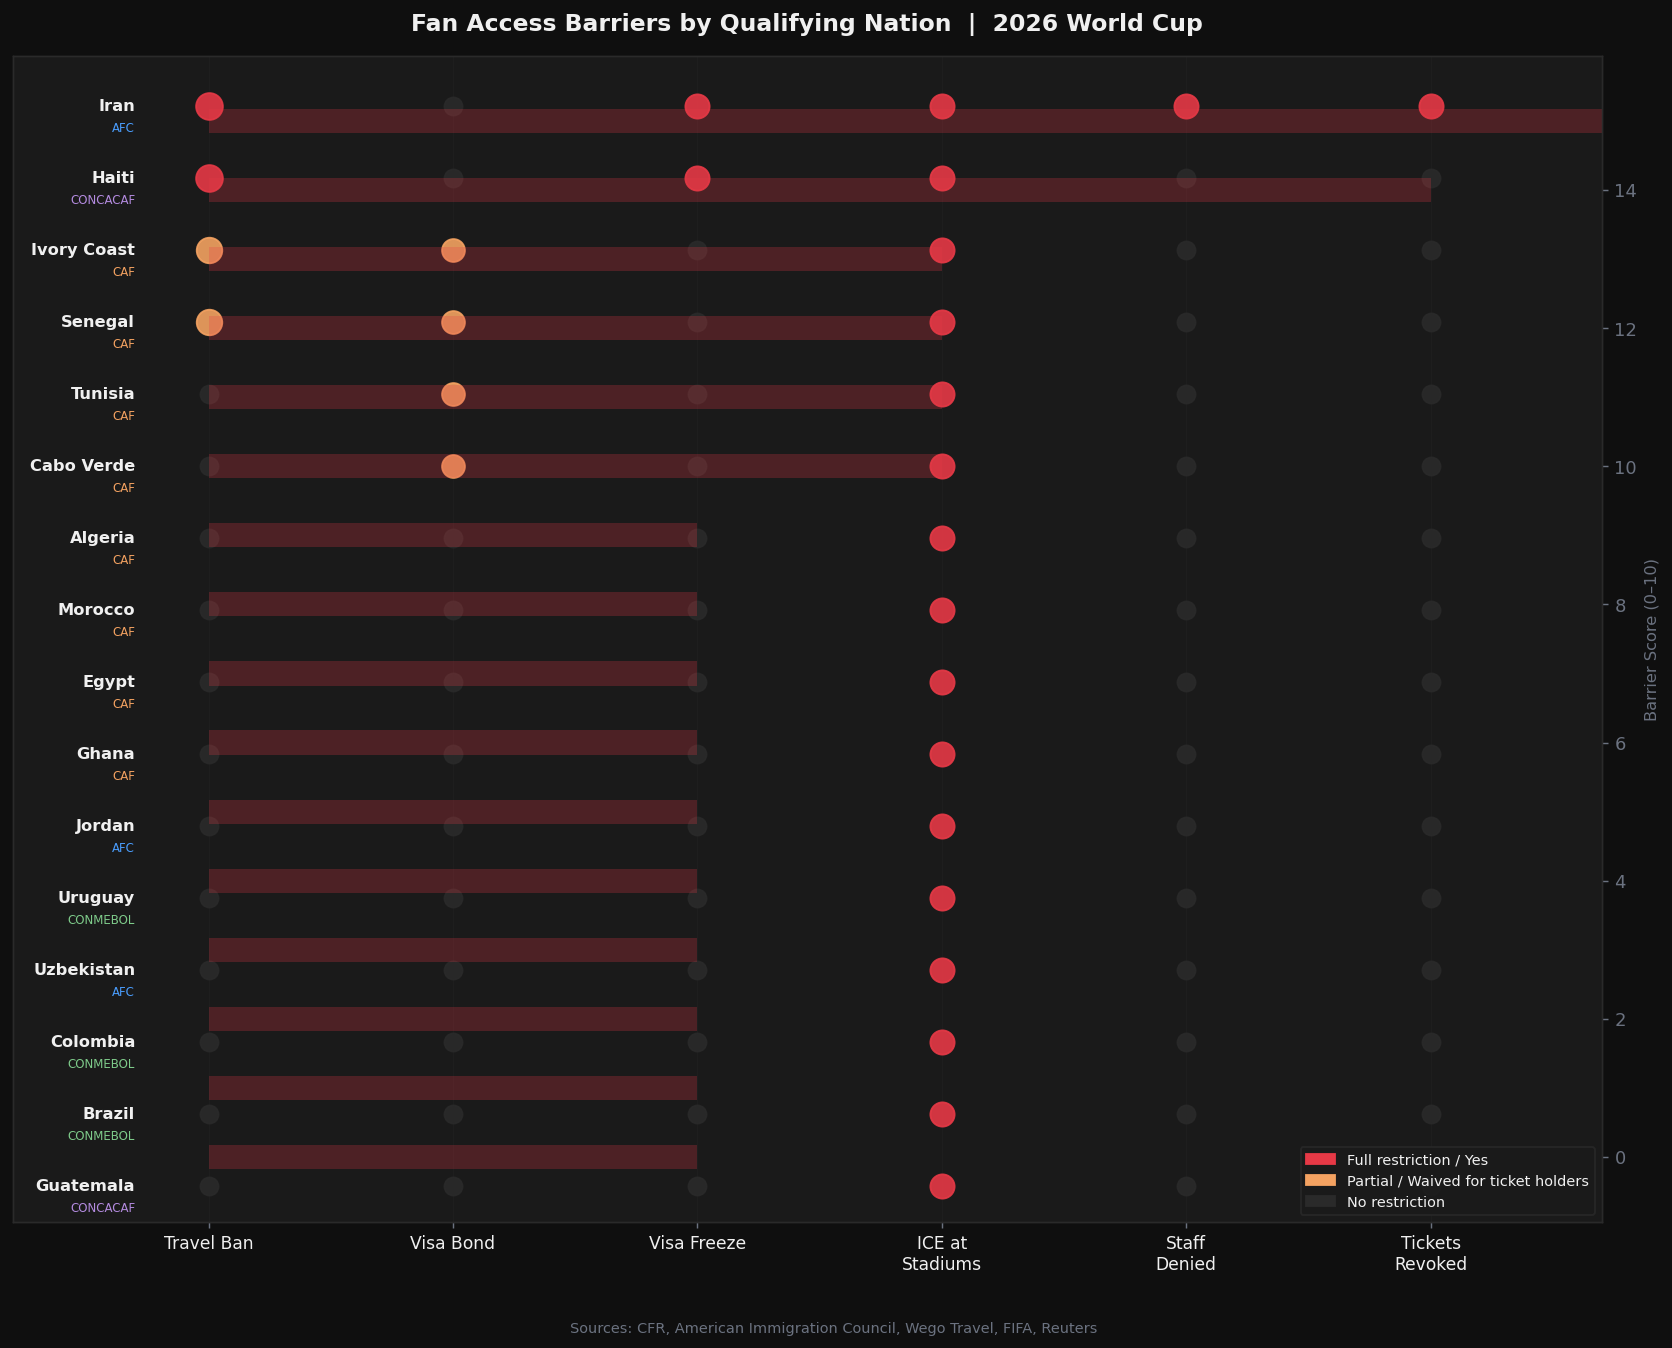

In [36]:
# ── Chart 5: Access barriers dot matrix ──────────────────────────────────────
affected = barriers[barriers["barrier_score"] >= 2].copy()
affected = affected.sort_values("barrier_score", ascending=False)

barrier_cols = [
    ("travel_ban_level",              "Travel Ban"),
    ("visa_bond_required",            "Visa Bond"),
    ("immigrant_visa_freeze",         "Visa Freeze"),
    ("ice_at_stadiums",               "ICE at\nStadiums"),
    ("staff_denied_entry",            "Staff\nDenied"),
    ("fan_ticket_allocation_revoked", "Tickets\nRevoked"),
]

conf_colours = {
    "CAF": "#f4a261", "AFC": "#4a9eff",
    "CONMEBOL": "#7ecb8a", "CONCACAF": "#b48be0",
    "UEFA": MUTED, "OFC": MUTED,
}

fig, ax = plt.subplots(figsize=(13, max(7, len(affected) * 0.5 + 2)))

n_countries = len(affected)
n_barriers  = len(barrier_cols)

for i, (_, row) in enumerate(affected.iterrows()):
    y = n_countries - i - 1
    conf_col = conf_colours.get(row["confederation"], WHITE)
    ax.text(-0.3, y, row["country"],
            ha="right", va="center", fontsize=9, color=WHITE, fontweight="bold")
    ax.text(-0.3, y - 0.3, row["confederation"],
            ha="right", va="center", fontsize=6.5, color=conf_col)

    for j, (col, _) in enumerate(barrier_cols):
        val = row[col]
        if col == "travel_ban_level":
            if val == "Full ban":
                colour, size = ACCENT, 220
            elif val == "Partial restriction":
                colour, size = GOLD, 200
            else:
                colour, size = GRID, 100
        else:
            if str(val).lower() in ["yes", "true", "1"]:
                colour, size = ACCENT, 180
            elif "waived" in str(val).lower():
                colour, size = GOLD, 160
            else:
                colour, size = GRID, 100

        ax.scatter(j, y, s=size, color=colour, zorder=3, alpha=0.9)

# Barrier score bar on right
score_ax = ax.twinx()
score_ax.set_facecolor(PANEL)
score_ax.barh(range(n_countries), affected["barrier_score"].values[::-1],
              height=0.35, color=ACCENT, alpha=0.25, zorder=1)
score_ax.set_xlim(0, 10)
score_ax.set_ylabel("Barrier Score (0–10)", fontsize=9, color=MUTED)
score_ax.tick_params(colors=MUTED)

ax.set_xlim(-0.8, n_barriers - 0.3)
ax.set_ylim(-0.5, n_countries - 0.3)
ax.set_xticks(range(n_barriers))
ax.set_xticklabels([b[1] for b in barrier_cols], fontsize=9.5, color=WHITE)
ax.set_yticks([])
ax.grid(axis="x", zorder=0, alpha=0.3)

legend_items = [
    mpatches.Patch(color=ACCENT, label="Full restriction / Yes"),
    mpatches.Patch(color=GOLD,   label="Partial / Waived for ticket holders"),
    mpatches.Patch(color=GRID,   label="No restriction"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=8,
          facecolor=PANEL, edgecolor=GRID, labelcolor=WHITE)

ax.set_title("Fan Access Barriers by Qualifying Nation  |  2026 World Cup",
             fontsize=13, fontweight="bold", pad=14)
fig.text(0.5, -0.03,
         "Sources: CFR, American Immigration Council, Wego Travel, FIFA, Reuters",
         ha="center", fontsize=8, color=MUTED)

plt.tight_layout()
plt.show()

What makes this chart striking is not the top two rows. Iran and Haiti, with their clusters of red dots, are the cases that made headlines. It is everything below them.

Scroll down past the full bans and the partial restrictions and you reach a long middle section of nations that technically have no travel ban, but whose fans are marked with the amber and red of the visa freeze column anyway. Algeria, Morocco, Egypt, Ghana, Jordan, Uruguay, Colombia, Brazil. These are not fringe qualifiers. Morocco reached the semi-finals in 2022 and travelled to Qatar in extraordinary numbers. Uruguay has been to every World Cup since 1930 bar one. Brazil is the most decorated footballing nation on earth, with one of the largest and most passionate travelling supporter cultures in the sport.

All of them are under an immigrant visa freeze. All of their fans face heightened scrutiny, extended processing times, and genuine uncertainty about whether their applications will succeed. And every single one of them, along with every other nation on this chart, is attending a tournament where ICE agents are confirmed inside the stadiums. That column lights up red across all 16 rows without exception.

The geography of the chart tells its own story too. Look at the confederation labels running down the left side. CAF, African football, dominates the top half. AFC and CONMEBOL fill the rest. These are the confederations whose fans travel furthest, spend the most nights in host cities, and contribute most to the economic windfall a World Cup is supposed to generate. They are also, overwhelmingly, the fans carrying the heaviest burden of restriction.

UEFA nations, England, Germany, Spain, France, Portugal, appear nowhere on this chart. Their fans will arrive freely, fill the premium seats, and leave. The atmosphere in the stands, the colour, the noise, the chaos that makes a World Cup a World Cup, that comes from everywhere else. And everywhere else is where the barriers are.

## 6. Composite Host Performance Score

Five dimensions scored 0–10, each based on published data:

| Dimension | What it measures |
|---|---|
| **Tourism Uplift** | Did visitor numbers increase in the host year vs prior year? |
| **Stadium Fill Rate** | How full were the stadiums? |
| **Ticket Accessibility** | Could ordinary fans afford to attend? |
| **Fan Access** | Could fans from all qualified nations travel freely? |
| **Hotel Readiness** | Were hotels prepared and priced appropriately? |

> *Scores are researcher-assigned based on published data, not modelled outputs.*

---

In [37]:
# ── Preview the host scores ───────────────────────────────────────────────────
print("=== Host Nation Performance Scores ===")
display(host_scores[["host", "year", "tourism_uplift_score", "attendance_fill_score",
                      "ticket_accessibility_score", "fan_access_score",
                      "hotel_readiness_score", "composite_score"]])

print(f"\nAverage composite score (prior hosts 2006–2022): "
      f"{host_scores[host_scores['year'] != 2026]['composite_score'].mean():.2f}")
print(f"USA 2026 composite score: "
      f"{host_scores[host_scores['year'] == 2026]['composite_score'].values[0]}")

=== Host Nation Performance Scores ===


,host,year,tourism_uplift_score,attendance_fill_score,ticket_accessibility_score,fan_access_score,hotel_readiness_score,composite_score
0,Germany,2006,8.0,9.8,8.5,9.5,9.5,9.1
1,South Africa,2010,6.5,9.4,8.0,9.0,7.5,8.1
2,Brazil,2014,8.5,9.7,7.5,9.5,8.0,8.6
3,Russia,2018,5.5,9.7,8.5,8.5,9.0,8.2
4,Qatar,2022,7.0,9.5,6.0,8.0,9.5,8.0
5,United States,2026,2.0,4.0,1.5,2.5,4.0,2.8



Average composite score (prior hosts 2006–2022): 8.40
USA 2026 composite score: 2.8


The numbers in that table require almost no interpretation. Five hosts, spanning twenty years, across four continents, in countries at wildly different levels of development and footballing culture, and every single one scores between 8.0 and 9.1. The range across two decades of World Cup hosting is 1.1 points. Germany to Qatar, summer to winter, Europe to the Gulf, the variation is essentially noise.

Then the United States: **2.8.**

Not 7. Not 6. Not even a struggling 5 that might suggest a host that tried and fell short. 2.8 out of 10, a score that sits closer to zero than to the worst prior host. South Africa in 2010 was widely criticised in the build-up: concerns about crime, infrastructure, whether African football was ready for this. It scored 8.1. Russia in 2018 faced active diplomatic boycotts from several Western governments. It scored 8.2. Qatar spent two decades under a cloud of controversy over human rights, labour conditions, and the fundamental question of whether it deserved the tournament at all. It scored 8.0.

The US scores 2.8.

Look at where those points are lost. Ticket accessibility: 1.5, the lowest possible score for a metric that measures whether ordinary people can afford to attend. Fan access: 2.5, reflecting the travel bans, visa freezes, and ICE presence documented in the previous section. Tourism uplift: 2.0, the only host in modern history projected to welcome fewer visitors in its tournament year than the year before. Hotel readiness: 4.0, with FIFA cancelling thousands of hotel reservations in March and properties that had priced rooms at World Cup premiums spending the spring cutting rates to fill beds.

The one dimension where the US was never going to struggle, stadium fill rate, comes in at 4.0. In a country that invented the sold-out sports event, that hosts the Super Bowl, the NBA Finals, and sold-out NFL games every single week of the season, the World Cup opened with empty seats.

### A note on methodology

The composite scores in this table are researcher-assigned rather than algorithmically modelled. Each of the five dimensions, tourism uplift, stadium fill rate, ticket accessibility, fan access, and hotel readiness, was scored on a 0 to 10 scale based on published data from the sources listed throughout this notebook. Prior hosts were scored using historical records and academic literature. The US 2026 score reflects data available as of June 2026, with some figures, particularly tourism projections, based on forecasts from Tourism Economics and the ITA rather than final confirmed numbers. The scores are intended to be directionally accurate and comparative rather than precisely quantitative. Readers are encouraged to interrogate the underlying data in the CSVs and draw their own conclusions.

Four years of preparation. Every structural advantage a host nation could ask for. A global sport at the peak of its popularity. **2.8 out of 10.**

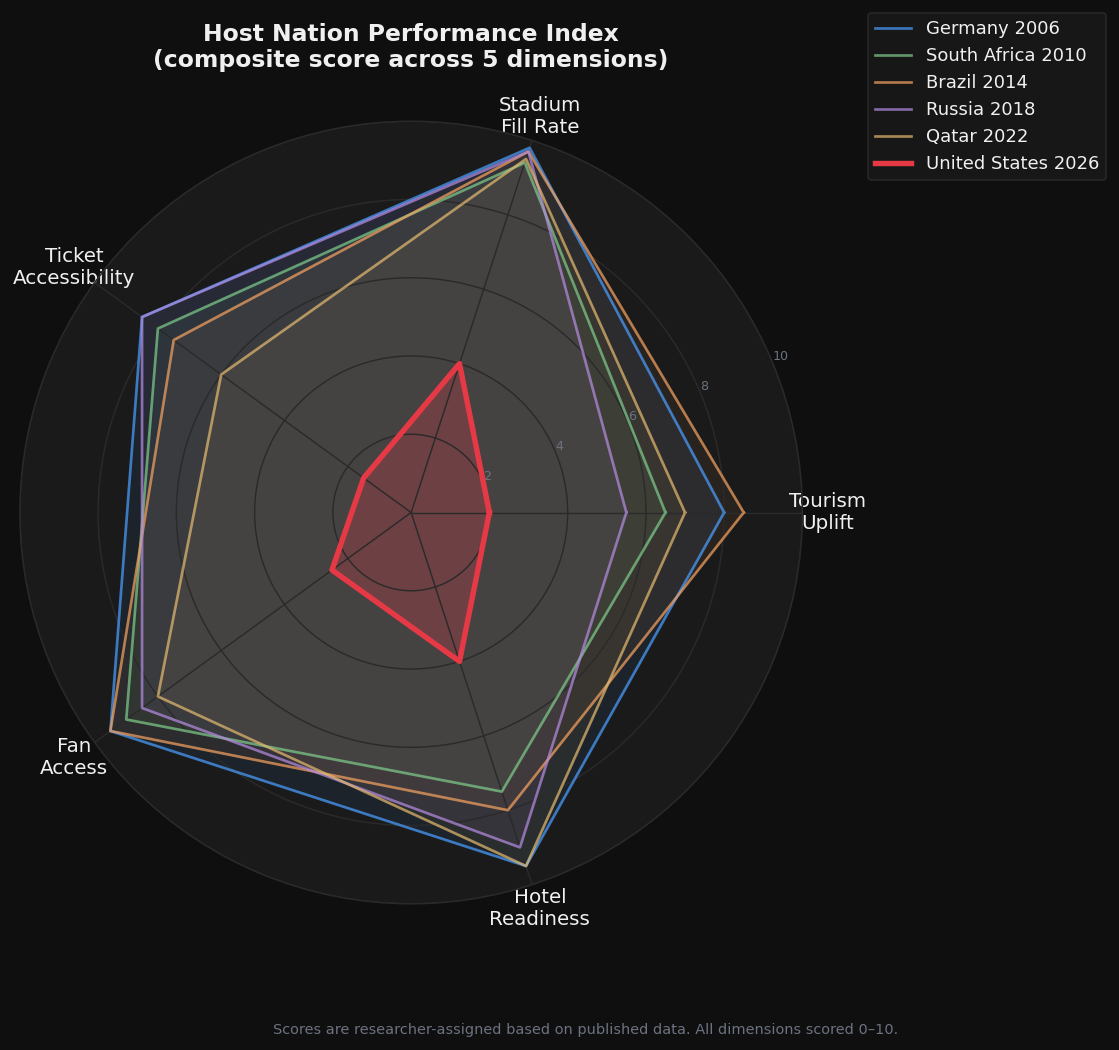

In [38]:
# ── Chart 6: Radar chart ──────────────────────────────────────────────────────
dimensions = [
    "tourism_uplift_score",
    "attendance_fill_score",
    "ticket_accessibility_score",
    "fan_access_score",
    "hotel_readiness_score",
]
dim_labels = [
    "Tourism\nUplift",
    "Stadium\nFill Rate",
    "Ticket\nAccessibility",
    "Fan\nAccess",
    "Hotel\nReadiness",
]
N      = len(dimensions)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

host_colours = {
    "Germany":       "#4a9eff",
    "South Africa":  "#7ecb8a",
    "Brazil":        "#f4a261",
    "Russia":        "#b48be0",
    "Qatar":         "#e2b96f",
    "United States": ACCENT,
}

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for _, row in host_scores.iterrows():
    host   = row["host"]
    values = [row[d] for d in dimensions] + [row[dimensions[0]]]
    colour = host_colours.get(host, WHITE)
    lw     = 3.0 if host == "United States" else 1.5
    alpha  = 1.0 if host == "United States" else 0.7

    ax.plot(angles, values, color=colour, linewidth=lw, alpha=alpha,
            label=f"{host} {row['year']}")
    ax.fill(angles, values, color=colour,
            alpha=0.25 if host == "United States" else 0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dim_labels, fontsize=11, color=WHITE)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(["2", "4", "6", "8", "10"], fontsize=7, color=MUTED)
ax.grid(color=GRID, linewidth=0.8)
ax.spines["polar"].set_color(GRID)
ax.set_title("Host Nation Performance Index\n(composite score across 5 dimensions)",
             fontsize=13, fontweight="bold", pad=30, color=WHITE)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15),
          fontsize=10, facecolor=PANEL, edgecolor=GRID, labelcolor=WHITE)

fig.text(0.5, 0.01,
         "Scores are researcher-assigned based on published data. All dimensions scored 0–10.",
         ha="center", fontsize=8, color=MUTED)

plt.tight_layout()
plt.show()

Five nations form a shape so consistent it looks almost deliberate, a broad, confident pentagon pushed out toward the edges of the chart, each line sitting close enough to the others that the differences between Germany and Qatar, Brazil and Russia, feel like minor variations on the same theme. This is what competent World Cup hosting looks like, rendered visually. It fills the space.

Then there is the red shape in the middle.

It does not look like a smaller version of the others. It looks like a different chart entirely, jagged, collapsed inward, asymmetric. The spike toward Stadium Fill Rate is the only dimension where the US reaches anything approaching the outer ring, and even that falls well short. Every other axis tells the same story: a host that did not show up.

The shape of the red polygon is itself revealing. A well-run tournament produces something roughly circular, balanced performance across all five dimensions. The US shape is elongated vertically toward Stadium Fill Rate at the top and pinched almost to nothing at Fan Access and Ticket Accessibility on the sides. It is the visual signature of a tournament that prioritised revenue over welcome, and infrastructure over inclusivity.

What the radar makes clear that the table of numbers does not is the distance. When you plot these scores spatially, the gap between the US and every prior host is not a matter of degree. It is a different order of magnitude. The red shape sits inside the ring marked 6 on every axis. The prior hosts never dip below it.

The outer pentagon is what the world expected. What it got is the small, sharp, red shape at the centre, a tournament that had everything and delivered far less than the least-resourced host in modern history.

## 7. Conclusions

The 2026 World Cup received **500 million ticket requests**. Demand was not the problem.

To put that number in context: the previous two tournaments combined attracted 50 million requests. This edition drew ten times that, from every corner of the world, for a sport at the absolute peak of its global popularity, with Messi and Ronaldo potentially making their final appearances on the biggest stage, and Neymar, whose injury-ravaged international career may finally have reached its end, playing what could be his last tournament. The appetite for this World Cup was, by any measure, extraordinary.

What happened next is the subject of this analysis.

Across every dimension measured, ticket pricing, stadium attendance, tourism, fan access, and a composite host performance index, the United States in 2026 has underperformed not just relative to expectations, but relative to every World Cup host in modern history. Countries with less money, less infrastructure, smaller stadiums, greater controversy, and far less time to prepare have all delivered better outcomes by these metrics.

The numbers tell a consistent story:

| Dimension | Finding |
|---|---|
| **Ticket prices** | The cheapest 2026 Final seat (USD 2,030) costs more than the most expensive seat at any prior World Cup Final |
| **Stadium fill rate** | Every prior host (1994-2022) achieved 94-99% fill rates. The 2026 US opening matches were not sold out |
| **Tourism** | The US is the only host in modern history projected to see a decline in visitors in its tournament year |
| **Fan access** | 4 qualified nations on full or partial travel bans; 39 countries facing restrictions; ICE deployed inside stadiums |
| **Composite score** | USA 2026: **2.8 / 10** vs prior host average of **8.4 / 10** |

None of this was inevitable. The United States had four years, world-class venues, the largest sports economy on earth, and a domestic football culture that has grown enormously since it last hosted in 1994. It had every advantage a host nation could ask for.

There is a structural problem worth acknowledging first, and it predates Trump entirely: **football is not America's sport.** In a country where the calendar is built around the NFL, the NBA, March Madness, and baseball, soccer has always occupied an awkward middle ground, genuinely beloved by immigrant communities and suburban youth leagues, but never quite crossing into the mainstream sporting consciousness the way it has on every other continent. When Brazil hosted in 2014, the country stopped. When Germany hosted in 2006, it was a matter of national identity. When the US hosts, a significant portion of the domestic population greets it with mild curiosity at best. The empty seats are partly a reflection of a country hosting the world's game without being fully converted to it.

That structural reality might have been managed, as it largely was in 1994, when organisational excellence and the enormous passion of immigrant fan communities filled stadiums to 99.8% capacity. The difference in 2026 is the political climate that made those very communities feel like a target rather than an asset.

**Donald Trump's** second administration has not merely complicated the logistics of hosting a World Cup. It has fundamentally altered what America signals to the world, and the world has responded accordingly.

The travel bans. The visa freezes. ICE agents confirmed inside stadiums. Phones searched at borders. A Somali referee denied entry to officiate matches he had been assigned. An Iranian squad commuting from Mexico because their support staff could not get visas. Moroccan fan groups with tickets and hotel bookings turned away at embassies. These are not bureaucratic inconveniences. They are the outputs of an administration that has made people of colour, Muslims, Latin Americans, Africans, and anyone who does not fit a narrow conception of who belongs in America feel, regardless of their legal status, that they are not welcome.

And this is the part that cuts deepest. The World Cup did not just suffer because of immigration policy in the technical, legal sense. It suffered because **Trump and his MAGA movement have poisoned the atmosphere for anyone who is not white in America.** Citizens. Permanent residents. Tourists with valid visas. People who have lived, worked, and paid taxes in the United States for decades. The message broadcast by this administration, in its executive orders, its rhetoric, its deployment of enforcement agencies at a sporting event, is that America is for some people and not others. That message was heard internationally. The 9.2% tourism decline did not happen because of visa paperwork. It happened because people made a choice about where they wanted to spend their money and their time, and they chose somewhere else.

There is a deeper irony here that the data cannot fully capture, but that deserves to be stated plainly. The United States is a country **built by immigrants**, constructed, literally and figuratively, on the labour, culture, and sacrifice of people who came from somewhere else. The diversity that made America the most aspirational destination on earth for most of the twentieth century, the idea that this was a place where anyone, from anywhere, could arrive and belong, was not a side effect of American greatness. It *was* American greatness. The food, the music, the sport, the culture, the economic engine: all of it shaped by people who were told, in some era or another, that they did not quite fit, and who built something extraordinary anyway.

No one is illegal on stolen land. The communities that Trump's administration has spent two terms targeting, Latino, Black, Muslim, immigrant, are not a threat to what America is. They are what America is. And in the summer of 2026, when the world came to celebrate the most universal sport on earth, those communities were made to feel that the celebration was not for them.

The stadiums showed it. The hotel occupancy showed it. The visa rejection letters showed it. The 176,000 unsold tickets showed it.

A composite host score of **2.8 out of 10**. The lowest in the history of the modern World Cup. In the country that, 32 years ago, showed everyone how it was done.

America was given four years to prepare. It had all the tools. What it lacked, what this administration actively dismantled, was the one thing no stadium, no budget, and no organisational framework can manufacture.

**The willingness to welcome people in.**

---

*Data sources: FIFA, ITA/NTTO, CFR, American Immigration Council, Statista, FootyStats, Financial Times, Tourism Economics, UN Tourism, The Conversation, Sports Illustrated, Gulf News, Reuters, NPR*